FEATURE ENGINEERING

In [58]:
import numpy as np
import pandas as pd
import sklearn
import matplotlib.pyplot as plt
import seaborn as sns

import os
os.chdir("/Users/arttusokka/Documents/AThesis/Prediciting-ATP-matches-outcome/data")

df= pd.read_csv("/Users/arttusokka/Documents/AThesis/Prediciting-ATP-matches-outcome/data/clean_and_raw/atp_matches_2000_2019_clean.csv")
df_cleaned = df.copy()

In [64]:
#RANDOMIZING THE WINNER AND LOSER COLUMNS
#-----------------------------------------------
#first, draw which side will be the winner.
np.random.seed(42)
mask = np.random.rand(len(df_cleaned)) < 0.5
#true -> winner -> player1, false -> winner -> player2


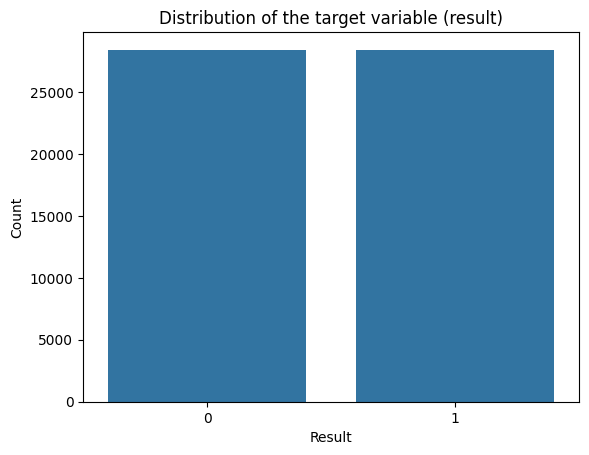

In [85]:
#differ winner and loser columns
winner_cols = [col for col in df_cleaned.columns if col.startswith("winner_")]
loser_cols = [col for col in df_cleaned.columns if col.startswith("loser_")]

#create player_1_ and player_2_ columns
for w_col in winner_cols:
    l_col = w_col.replace("winner_", "loser_")
    
    base_name = w_col.replace("winner_", "")
    
    df_cleaned[f"player1_{base_name}"] = np.where(
        mask,
        df_cleaned[w_col],
        df_cleaned[l_col]
    )
    
    df_cleaned[f"player2_{base_name}"] = np.where(
        mask,
        df_cleaned[l_col],
        df_cleaned[w_col]
    )

#target variable (if winner = player1 -> 1, else 0)
df_cleaned["result"] = np.where(mask, 1, 0)

#let's drop the original winner and loser columns.
df_cleaned = df_cleaned.drop(columns=winner_cols + loser_cols)

#Lastly, create a graph showing the %-distribution of the target variable.
sns.countplot(x="result", data=df_cleaned)
plt.title("Distribution of the target variable (result)")
plt.xlabel("Result")
plt.ylabel("Count")
plt.show()

In [86]:
#sort the data by date (already done in cleaning, but just to be sure)
df_cleaned = df_cleaned.sort_values("tourney_date").reset_index(drop=True)

#THE BASE DIFFERENTIAL VARIABLES
#1. Rank differential, note: lower rank is better (2-1)
df_cleaned["rank_diff"] = df_cleaned["player2_rank"] - df_cleaned["player1_rank"]

#2. Rank points differential, note: higher rank points is better (1-2)
df_cleaned["rank_points_diff"] = df_cleaned["player1_rank_points"] - df_cleaned["player2_rank_points"]

#3. Age differential (1-2)
df_cleaned["age_diff"] = df_cleaned["player1_age"] - df_cleaned["player2_age"]

#4. Height differential (1-2)
df_cleaned["height_diff"] = df_cleaned["player1_ht"] - df_cleaned["player2_ht"]

#5. Hand matchup dummy coding (1 if different, 0 if same). Could do more detailed
#but most likely wouldn't add much value because the only big difference is between same and different hand.
df_cleaned["different_hand"] = (
    df_cleaned["player1_hand"] != df_cleaned["player2_hand"]
).astype(int)


In [92]:
#ELO
ELO_START = 1500
K = 32
SCALE = 400
#Expected outcome Player 1 - Player 2
def expected_score(r1, r2, scale=400):
    return 1 / (1 + 10 ** ((r2 - r1) / scale))

#ELO change
def update_elo(r1, r2, score1, k=32, scale=400):
    e1 = expected_score(r1, r2, scale)
    r1_new = r1 + k * (score1 - e1) #playr1 elo update
    r2_new = r2 - k * (score1 - e1) #player2 elo update (note the minus, because score1 is from player1 perspective)
    return r1_new, r2_new

#Empty columns for pre-match ELO ratings
df_cleaned["elo_p1_pre"] = np.nan
df_cleaned["elo_p2_pre"] = np.nan

#ELO memory
elo_dict = {}
df_cleaned = df_cleaned.sort_values("tourney_date").reset_index(drop=True)

#Calculate ELO ratings iteratively
for i, row in df_cleaned.iterrows():
    
    p1 = row["player1_id"]
    p2 = row["player2_id"]
    score1 = row["result"]  # 1 = player1 wins
    
    #Current ELO or DEFAULT=1500
    r1 = elo_dict.get(p1, ELO_START)
    r2 = elo_dict.get(p2, ELO_START)
    
    #save pre-match ELO ratings
    df_cleaned.at[i, "elo_p1_pre"] = r1
    df_cleaned.at[i, "elo_p2_pre"] = r2
    
    #Update ELO
    r1_new, r2_new = update_elo(r1, r2, score1, k=K)
    
    elo_dict[p1] = r1_new
    elo_dict[p2] = r2_new
#-----   
#ELO differential feature
df_cleaned["elo_diff"] = (df_cleaned["elo_p1_pre"] - df_cleaned["elo_p2_pre"])
df_cleaned.groupby("result")["elo_diff"].mean()    

result
0   -0.120689
1    0.384170
Name: elo_diff, dtype: float64

In [ ]:
#SURFACE-SPECIFIC ELO RATINGS
#Empty columns for pre-match surface-specific ELO ratings
df_cleaned["elo_p1_pre_surface"] = np.nan
df_cleaned["elo_p2_pre_surface"] = np.nan
df_cleaned = df_cleaned.sort_values("tourney_date").reset_index(drop=True)

surface_elo_dict = {}
for i, row in df_cleaned.iterrows():
    
    p1 = row["player1_id"]
    p2 = row["player2_id"]
    surface = row["surface"]
    score1 = row["result"]  # 1 = player1 wins
    
    #Keys for surface-specific ELO
    key1 = (p1, surface)
    key2 = (p2, surface)
    
    #Current ELO or DEFAULT=1500
    r1 = surface_elo_dict.get(key1, ELO_START)
    r2 = surface_elo_dict.get(key2, ELO_START)
    
    #save pre-match surface-specific ELO ratings
    df_cleaned.at[i, "elo_p1_pre_surface"] = r1
    df_cleaned.at[i, "elo_p2_pre_surface"] = r2
    
    #Update ELO
    r1_new, r2_new = update_elo(r1, r2, score1, k=K)
    
    surface_elo_dict[key1] = r1_new
    surface_elo_dict[key2] = r2_new
    
#Surface-specific ELO differential feature
df_cleaned["elo_diff_surface"] = (df_cleaned["elo_p2_pre_surface"] - df_cleaned["elo_p1_pre_surface"])
df_cleaned.groupby("result")["elo_diff_surface"].mean()

result
0   -0.197455
1    0.138242
Name: elo_diff_surface, dtype: float64